In [16]:
#------ 
# Project Name: fig S1 code
# Description : 
#------ 

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
MODEL_ORDER = ["DURW-p", "BI", "Meta"]

def read_waic_csv(csv_path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    need = {"Model_names", "elpd_waic"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"WAIC表缺少列: {missing}")
    df = df.copy()
    df["Model_names"] = df["Model_names"].astype(str)
    df = df[df["Model_names"].isin(MODEL_ORDER)]
    min_elpd = df["elpd_waic"].min()
    df["delta_elpd_waic"] = df["elpd_waic"] - min_elpd
    df["Model_names"] = pd.Categorical(df["Model_names"], categories=MODEL_ORDER, ordered=True)
    df = df.sort_values("Model_names")
    return df[["Model_names", "delta_elpd_waic"]]

def read_bmc_csv(csv_path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    need = {"Model_names", "Estimated_model_frequency", "Exceedance_prob"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"BMC lack: {missing}")
    df = df.copy()
    df["Model_names"] = df["Model_names"].astype(str)
    df = df[df["Model_names"].isin(MODEL_ORDER)]
    df["Model_names"] = pd.Categorical(df["Model_names"], categories=MODEL_ORDER, ordered=True)
    df = df.sort_values("Model_names")
    return df[["Model_names", "Estimated_model_frequency", "Exceedance_prob"]]


def _style_science(ax, x_tick_rotation=0):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for s in ["left", "bottom"]:
        ax.spines[s].set_linewidth(0.8)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.8, direction="out", labelsize=9)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=x_tick_rotation)
    for label in ax.get_xticklabels():
        label.set_fontsize(9)
    for label in ax.get_yticklabels():
        label.set_fontsize(9)

def _annotate_bars(ax, xs, ys, fmt="{:.2f}", dy=0.01):
    ymax = ax.get_ylim()[1]
    for x, y in zip(xs, ys):
        ax.text(x, y + max(dy * ymax, 0.02), fmt.format(y),
                ha="center", va="bottom", fontsize=9)

def plot_model_triplet(ax_list, waic_df: pd.DataFrame, bmc_df: pd.DataFrame,
                       species_label: str = "Human"):
    if len(ax_list) != 3:
        raise ValueError("ax_list 需要包含 3 个子图轴：ΔWAIC / EMF / EP")
    ax_w, ax_f, ax_e = ax_list

    # --- ΔELPD WAIC ---
    dfw = waic_df.copy()
    x = np.arange(len(dfw))
    y = dfw["delta_elpd_waic"].to_numpy()
    bars = ax_w.bar(x, y, width=0.6)
    ax_w.set_xticks(x, dfw["Model_names"])
    ax_w.set_ylabel("ΔELPD WAIC", fontsize=10)
    ax_w.set_title(f"ΔELPD WAIC ({species_label})", fontsize=11, pad=6)
    _style_science(ax_w)
    _annotate_bars(ax_w, x, y, fmt="{:.2f}")

    # --- Estimated model frequency ---
    dff = bmc_df.copy()
    x = np.arange(len(dff))
    y = dff["Estimated_model_frequency"].to_numpy()
    ax_f.bar(x, y, width=0.6)
    ax_f.set_xticks(x, dff["Model_names"])
    ax_f.set_ylabel("Estimated model frequency", fontsize=10)
    ax_f.set_title(f"Model Frequency ({species_label})", fontsize=11, pad=6)
    # chance level = 1/3
    ax_f.axhline(1/3, color="red", linestyle="--", linewidth=1.0)
    _style_science(ax_f)
    _annotate_bars(ax_f, x, y, fmt="{:.2f}")

    # --- Exceedance probability ---
    dfe = bmc_df.copy()
    x = np.arange(len(dfe))
    y = dfe["Exceedance_prob"].to_numpy()
    ax_e.bar(x, y, width=0.6)
    ax_e.set_xticks(x, dfe["Model_names"])
    ax_e.set_ylabel("Exceedance probability", fontsize=10)
    ax_e.set_title(f"Exceedance Prob. ({species_label})", fontsize=11, pad=6)
    ax_e.axhline(0.95, color="red", linestyle="-", linewidth=1.0)
    ax_e.set_ylim(0, 1.05)  # 
    _style_science(ax_e)
    _annotate_bars(ax_e, x, y, fmt="{:.2f}")


def _prep_waic(df_raw):
    """ ['Model_names','delta_elpd_waic'] """
    df = df_raw.copy()
    if "delta_elpd_waic" not in df.columns:
        if "elpd_waic" not in df.columns:
            raise ValueError("WAIC need 'elpd_waic' or 'delta_elpd_waic' 列。")
        df = (df.groupby("Model_names", as_index=False)["elpd_waic"]
                .min())
        min_elpd = df["elpd_waic"].min()
        df["delta_elpd_waic"] = df["elpd_waic"] - min_elpd

    df = df[df["Model_names"].isin(MODEL_ORDER)].copy()
    df["Model_names"] = pd.Categorical(df["Model_names"], categories=MODEL_ORDER, ordered=True)
    df = df.sort_values("Model_names")
    return df[["Model_names", "delta_elpd_waic"]]

def _prep_bmc(df_raw):
    """return df of ['Model_names','Estimated_model_frequency','Exceedance_prob']"""
    need = {"Model_names", "Estimated_model_frequency", "Exceedance_prob"}
    miss = need - set(df_raw.columns)
    if miss:
        raise ValueError(f"BMC lack: {miss}")
    df = df_raw.copy()
    df = df[df["Model_names"].isin(MODEL_ORDER)].copy()
    df["Model_names"] = pd.Categorical(df["Model_names"], categories=MODEL_ORDER, ordered=True)
    df = df.sort_values("Model_names")
    return df[["Model_names", "Estimated_model_frequency", "Exceedance_prob"]]

def plot_model_triplet(ax_list, waic_df, bmc_df, species_label: str = "Human", color = "#BDBDBD"):
    if len(ax_list) != 3:
        raise ValueError("ax_list  need ：ΔWAIC / EMF / EP")
    ax_w, ax_f, ax_e = ax_list

    # --- ΔELPD WAIC ---
    dfw = _prep_waic(waic_df)
    x = np.arange(len(dfw))
    y = dfw["delta_elpd_waic"].to_numpy()
    # ax_w.bar(x, y, width=0.6)
    ax_w.bar(x, y, width=0.6, color=color, edgecolor="black", linewidth=0.6)
    ax_w.set_xticks(x, dfw["Model_names"])
    ax_w.set_ylabel("ΔELPD WAIC", fontsize=10)
    ax_w.set_title(f"ΔELPD WAIC ({species_label})", fontsize=11, pad=6)
    _style_science(ax_w)
    _annotate_bars(ax_w, x, y, fmt="{:.2f}")

    # --- Estimated model frequency ---
    dff = _prep_bmc(bmc_df)
    x = np.arange(len(dff))
    y = dff["Estimated_model_frequency"].to_numpy()
    ax_f.bar(x, y, width=0.6, color=color, edgecolor="black", linewidth=0.6)
    ax_f.set_xticks(x, dff["Model_names"])
    ax_f.set_ylabel("Estimated model frequency", fontsize=10)
    ax_f.set_title(f"Model Frequency ({species_label})", fontsize=11, pad=6)
    ax_f.axhline(1/3, color="red", linestyle="--", linewidth=1.0)  # chance level
    _style_science(ax_f)
    _annotate_bars(ax_f, x, y, fmt="{:.2f}")

    # --- Exceedance probability ---
    x = np.arange(len(dff))
    y = dff["Exceedance_prob"].to_numpy()
    ax_e.bar(x, y, width=0.6, color=color, edgecolor="black", linewidth=0.6)
    ax_e.set_xticks(x, dff["Model_names"])
    ax_e.set_ylabel("Exceedance probability", fontsize=10)
    ax_e.set_title(f"Exceedance Prob. ({species_label})", fontsize=11, pad=6)
    ax_e.axhline(0.95, color="red", linestyle="-", linewidth=1.0)   # EP=0.95 
    ax_e.set_ylim(0, 1.05)
    _style_science(ax_e)
    _annotate_bars(ax_e, x, y, fmt="{:.2f}")


In [18]:
human_waic_df = pd.read_csv('./data/FigS1_Human_Hier_results_with_BI_Meta.csv')
monkey_waic_df = pd.read_csv('./data/FigS1_Monkey_Hier_results_with_BI_Meta.csv')
human_XP_df = pd.read_csv('./data/FigS1_Human_groupBMC_with_BI_Meta.csv')
monkey_XP_df = pd.read_csv('./data/FigS1_Monkey_groupBMC_with_BI_Meta.csv')

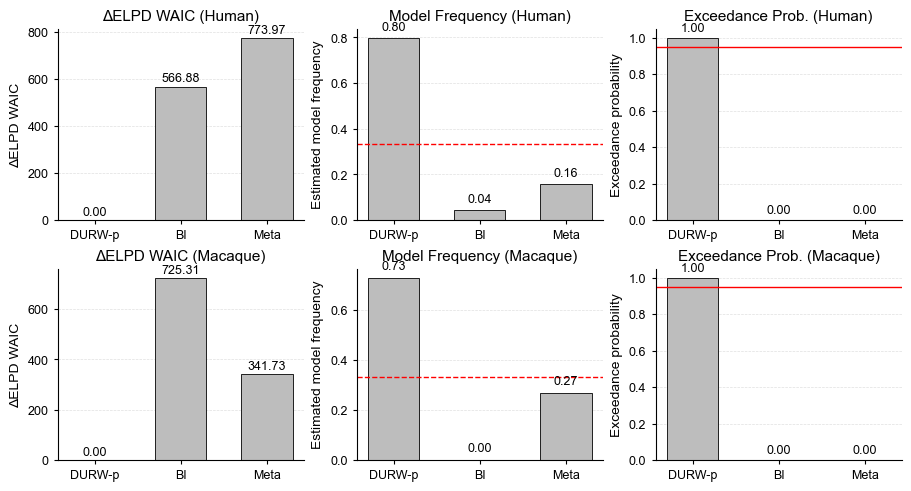

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(9.0, 4.8), constrained_layout=True)
plot_model_triplet(axes[0, :], human_waic_df, human_XP_df, species_label="Human")
plot_model_triplet(axes[1, :], monkey_waic_df, monkey_XP_df, species_label="Macaque")
for j, title in enumerate(["ΔELPD WAIC", "Estimated model frequency", "Exceedance probability"]):
    axes[0, j].set_xlabel("")
    axes[1, j].set_xlabel("")